In [1]:
# Install TensorFlow with GPU support for Python 3.10.15
# Your system: NVIDIA RTX 4080 with CUDA 13.0 driver support

# Step 1: Install TensorFlow with CUDA support (bundles CUDA libraries)
# tensorflow[and-cuda] includes all necessary CUDA/cuDNN libraries
print("Installing TensorFlow with GPU support...")
%pip install tensorflow[and-cuda]>=2.15.0 tensorboard>=2.15.0 scikit-learn>=1.2.2 seaborn>=0.13.2 opencv-python>=4.11.0.86 matplotlib>=3.10.0 numpy>=1.26.4 pandas>=2.2.2 -q

print("\nInstallation complete!")
print("IMPORTANT: RESTART THE KERNEL after this cell completes")
print("Then run Cell 1 to verify GPU detection")

Installing TensorFlow with GPU support...
zsh:1: no matches found: tensorflow[and-cuda]


Note: you may need to restart the kernel to use updated packages.

Installation complete!
IMPORTANT: RESTART THE KERNEL after this cell completes
Then run Cell 1 to verify GPU detection


In [2]:
# Import TensorFlow and verify GPU
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

# Check for GPU
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"GPU detected: {gpus[0].name}")
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected - will use CPU")


2025-12-25 16:32:25.240875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-25 16:32:25.954635: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-25 16:32:28.480638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU detected: /physical_device:GPU:0


In [3]:
# Import libraries
from tensorflow.keras import losses
from tensorflow.keras import optimizers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# Configure GPU (if available)
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print(f"GPU configured: {gpus[0].name}")
else:
    print("Using CPU")

GPU configured: /physical_device:GPU:0


# Custom CNN Model for COVID-19 Image Classification

## Model Outline

This notebook implements a **custom CNN model from scratch** for COVID-19 chest X-ray classification. This model will serve as a **baseline for comparison** with pre-trained models from Hugging Face (which will use RAG later).

**Goal**: Create and train a custom model, then compare its performance with external models.

### Overall Structure:
1. **Configuration & Setup** - Define paths, hyperparameters, and constants
2. **Data Loading** - Load train/val splits and create data generators
3. **Data Preprocessing** - Image normalization, resizing, and augmentation
4. **Model Architecture** - Custom CNN design (see tips below)
5. **Model Compilation** - Loss function, optimizer, and metrics
6. **Training** - Training loop with callbacks
7. **Evaluation** - Metrics calculation and visualization
8. **Model Saving** - Save model weights and architecture


## 1. Configuration & Setup


In [4]:
# Configuration and hyperparameters
from pathlib import Path
import os

# Data paths
DATA_DIR = Path('data')
TRAIN_SPLIT_CSV = DATA_DIR / 'train_split.csv'
VAL_SPLIT_CSV = DATA_DIR / 'val_split.csv'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Model hyperparameters
IMG_SIZE = 256  # Images are already 256px
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
NUM_CLASSES = 4  # Typical, Negative, Atypical, Indeterminate

# Class labels mapping
CLASS_LABELS = {
    0: 'Negative for Pneumonia',
    1: 'Typical Appearance',
    2: 'Indeterminate Appearance',
    3: 'Atypical Appearance'
}

# Model save paths
MODEL_WEIGHTS_PATH = MODEL_DIR / 'custom_covid19_model.weights.h5'
MODEL_ARCHITECTURE_PATH = MODEL_DIR / 'custom_covid19_model.json'
FEATURES_DIR = MODEL_DIR / 'features'
FEATURES_DIR.mkdir(exist_ok=True)

print("Configuration loaded:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Number of classes: {NUM_CLASSES}")


Configuration loaded:
  Image size: 256x256
  Batch size: 64
  Epochs: 50
  Learning rate: 0.001
  Number of classes: 4


## 2. Data Loading & Preprocessing


In [5]:
# Load train/val splits
train_df = pd.read_csv(TRAIN_SPLIT_CSV)
val_df = pd.read_csv(VAL_SPLIT_CSV)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nClass distribution in training set:")
print(train_df['label_id'].value_counts())


Training samples: 5067
Validation samples: 1267

Class distribution in training set:
label_id
Typical Appearance          2406
Negative for Pneumonia      1389
Indeterminate Appearance     886
Atypical Appearance          386
Name: count, dtype: int64


In [6]:
train_df.head()

,ImageInstanceUID,StudyInstanceUID,label_id,study_label,height,width,boxes,image_label,image_path,image_exists
0,000a312787f2,5776db0cec75,Typical Appearance,1,3488,4256,"[{'x': 789.28836, 'y': 582.43035, 'width': 102...",opacity 1 789.28836 582.43035 1815.94498 2499....,data/256px/train/train/5776db0cec75_81456c9c54...,True
1,000c3a3f293f,ff0879eb20ed,Negative for Pneumonia,0,2320,2832,"[{'x': 0, 'y': 0, 'width': 1, 'height': 1}]",none 1 0 0 1 1,data/256px/train/train/ff0879eb20ed_d8a644cc4f...,True
2,001398f4ff4f,28dddc8559b2,Atypical Appearance,3,3520,4280,"[{'x': 2729, 'y': 2181.33331, 'width': 948.000...",opacity 1 2729 2181.33331 3677.00012 2785.33331,data/256px/train/train/28dddc8559b2_4d47bc042e...,True
3,001bd15d1891,dfd9fdd85a3e,Typical Appearance,1,2800,3408,"[{'x': 623.23328, 'y': 1050, 'width': 714, 'he...",opacity 1 623.23328 1050 1337.23328 2156 opaci...,data/256px/train/train/dfd9fdd85a3e_49170afa4f...,True
4,0022227f5adf,84543edc24c2,Indeterminate Appearance,2,2539,3050,"[{'x': 1857.2065, 'y': 508.30565, 'width': 376...",opacity 1 1857.2065 508.30565 2233.23384 907.8...,data/256px/train/train/84543edc24c2_82f65ab98e...,True


## 3. Data Preprocessing & Augmentation


In [7]:
# Custom data generator for loading images
def load_and_preprocess_image(image_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load and preprocess a single image"""
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0  # Normalize to [0, 1]
    return img

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation
val_datagen = ImageDataGenerator()

print("Data generators created with augmentation for training set")


Data generators created with augmentation for training set


## 4. Model Architecture - Custom CNN


In [8]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, 
    Dropout, GlobalAveragePooling2D, Activation, Dense, Add, Input
)
from tensorflow.keras.layers import Multiply, Reshape

def se_block(x, ratio=16):
    """
    Squeeze-and-Excitation (SE) Block for channel attention
    
    This is a more efficient version of channel attention that:
    1. Squeezes: Global Average Pooling to get channel-wise statistics
    2. Excites: Two Dense layers to learn channel importance
    3. Scales: Multiplies original features by learned attention weights
    
    Args:
        x: Input tensor (batch, height, width, channels)
        ratio: Reduction ratio for the bottleneck (default 16)
    
    Returns:
        Tensor with same shape as input, but with channel-wise attention applied
    """
    channels = x.shape[-1]
    
    # Step 1: Squeeze - Global Average Pooling
    # Reduces (batch, H, W, C) → (batch, C)
    se = GlobalAveragePooling2D()(x)
    
    # Reshape to (batch, 1, 1, C) for broadcasting
    se = Reshape((1, 1, channels))(se)
    
    # Step 2: Excitation - Learn channel importance
    # First Dense: Reduce dimensionality (bottleneck)
    se = Dense(channels // ratio, activation='relu')(se)
    # Second Dense: Restore to original channels, output sigmoid (0-1 weights)
    se = Dense(channels, activation='sigmoid')(se)
    
    # Step 3: Scale - Multiply original features by attention weights
    # Broadcasting: (batch, 1, 1, C) * (batch, H, W, C) → (batch, H, W, C)
    return Multiply()([x, se])


def residual_block(x, filters, kernel_size=3, stride=1, use_se=True):
    """
    Residual Block with Skip Connection (ResNet-style)
    
    This block implements: output = activation(conv_layers(x) + x)
    The skip connection allows gradients to flow directly, solving vanishing gradient problem.
    
    Args:
        x: Input tensor
        filters: Number of output filters
        kernel_size: Size of convolution kernel (default 3x3)
        stride: Stride for convolution (1 = same size, 2 = half size)
        use_se: Whether to apply SE attention (default True)
    
    Returns:
        Output tensor with residual connection applied
    """
    shortcut = x  # Save input for skip connection
    
    # Main path: Two conv layers
    # First conv
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)  # Lower dropout in early layers
    
    # Second conv
    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    
    # Skip connection: If dimensions don't match, use 1x1 conv to adjust
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    
    # Add skip connection: output = main_path + shortcut
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    
    # Apply SE attention if requested
    if use_se:
        x = se_block(x, ratio=16)
    
    return x


def create_custom_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Improved CNN Model with Residual Connections and Attention
    
    Architecture improvements:
    1. Residual blocks with skip connections (ResNet-style)
    2. Squeeze-and-Excitation attention mechanisms
    3. Strided convolutions instead of MaxPooling (more learnable)
    4. Progressive dropout (lower in early layers, higher in later layers)
    5. Deeper feature extraction (1024 → 512 → classification)
    
    This architecture is inspired by ResNet and EfficientNet, combining:
    - Residual learning for better gradient flow
    - Channel attention for feature selection
    - Better regularization for generalization
    """
    inputs = Input(shape=input_shape)
    x = inputs
    
    # Initial Convolution Block
    # Large kernel (7x7) with stride 2 for initial downsampling
    # This is more efficient than small kernels + pooling
    x = Conv2D(32, (7, 7), strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    # Output: 64x64x32 (down from 256x256x3)
    

    # Residual Blocks with Increasing Filters


    # Residual Block 1: 64 filters
    # Stride 1 means same spatial size (64x64)
    x = residual_block(x, filters=64, stride=1, use_se=True)
    x = residual_block(x, filters=64, stride=1, use_se=True)
    # Output: 64x64x64
    
    # Residual Block 2: 128 filters, stride 2 for downsampling
    # Stride 2 halves spatial dimensions (64x64 → 32x32)
    x = residual_block(x, filters=128, stride=2, use_se=True)
    x = residual_block(x, filters=128, stride=1, use_se=True)
    # Output: 32x32x128
    
    # Residual Block 3: 256 filters
    x = residual_block(x, filters=256, stride=2, use_se=True)
    x = residual_block(x, filters=256, stride=1, use_se=True)
    # Output: 16x16x256
    
    # Residual Block 4: 512 filters
    x = residual_block(x, filters=512, stride=2, use_se=True)
    x = residual_block(x, filters=512, stride=1, use_se=True)
    # Output: 8x8x512
    

    # Feature Extraction Head

    # Global Average Pooling: (batch, 8, 8, 512) → (batch, 512)
    x = GlobalAveragePooling2D()(x)
    
    # First Dense layer: Larger feature dimension for better representation
    x = Dense(1024, activation='relu', name='feature_extraction')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Higher dropout in fully connected layers
    
    # Second Dense layer: Additional layer for feature refinement
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    

    # Classification Head
    outputs = Dense(num_classes, activation='softmax', name='classification')(x)
    
    # Create model using Functional API
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

# Create the model
model = create_custom_cnn_model()
model.summary()


I0000 00:00:1766701951.377392   63453 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13510 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      4,736 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p

 Total params: 12,317,372 (46.99 MB)

 Trainable params: 12,304,636 (46.94 MB)

 Non-trainable params: 12,736 (49.75 KB)

## 5. Model Compilation


In [9]:
# Compile the model
model.compile(
    optimizer=optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),  # Use sparse since labels are integers
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: Sparse Categorical Crossentropy")
print(f"  Metrics: Accuracy")


Model compiled successfully!
  Optimizer: Adam (lr=0.001)
  Loss: Sparse Categorical Crossentropy
  Metrics: Accuracy


## 6. Training Setup - Callbacks


In [10]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, 
    CSVLogger, TensorBoard
)

# Define callbacks
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=str(MODEL_WEIGHTS_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Log training history
    CSVLogger(
        filename=str(MODEL_DIR / 'training_history.csv'),
        append=False
    ),
    
    # TensorBoard logging (optional - for visualization)
    TensorBoard(
        log_dir=str(MODEL_DIR / 'logs'),
        histogram_freq=1
    )
]

print("Callbacks configured:")
print("  - ModelCheckpoint: Save best model weights")
print("  - EarlyStopping: Stop if no improvement for 10 epochs")
print("  - ReduceLROnPlateau: Reduce LR when validation plateaus")
print("  - CSVLogger: Save training history")
print("  - TensorBoard: Log training metrics")


Callbacks configured:
  - ModelCheckpoint: Save best model weights
  - EarlyStopping: Stop if no improvement for 10 epochs
  - ReduceLROnPlateau: Reduce LR when validation plateaus
  - CSVLogger: Save training history
  - TensorBoard: Log training metrics


## 7. Data Generators for Training


In [11]:
# Create custom data generator class
class CustomDataGenerator(tf.keras.utils.Sequence):
    """Custom data generator for loading images and labels"""
    
    def __init__(self, dataframe, batch_size=BATCH_SIZE, shuffle=True, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        
        X = np.zeros((len(batch_df), IMG_SIZE, IMG_SIZE, 3))
        y = np.zeros(len(batch_df))
        
        for i, (_, row) in enumerate(batch_df.iterrows()):
            # Load and preprocess image
            img = load_and_preprocess_image(row['image_path'])
            
            # Apply augmentation if training
            if self.augment:
                img = train_datagen.random_transform(img)
            
            X[i] = img
            y[i] = row['study_label']  # Use numeric label
        
        return X, y
    
    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create data generators
train_generator = CustomDataGenerator(
    train_df, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    augment=True
)

val_generator = CustomDataGenerator(
    val_df, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    augment=False
)

print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")


Training batches: 80
Validation batches: 20


## 8. Model Training


In [12]:
# Train the model
print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Verify GPU is available before training
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"\nGPU detected: {len(gpus)} GPU(s) available")
    print(f"   Using GPU: {gpus[0].name}")
    print("\nMonitor GPU usage: Run 'nvidia-smi -l 1' in terminal")
else:
    print("\nWARNING: No GPU detected!")
    print("   Training will use CPU (much slower)")
    print("   Consider restarting kernel and checking GPU setup in Cell 3")

print("\n" + "=" * 60)
print("Starting training...")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("=" * 60 + "\n")

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("Training completed!")
print("=" * 60)


MODEL TRAINING

GPU detected: 1 GPU(s) available
   Using GPU: /physical_device:GPU:0

Monitor GPU usage: Run 'nvidia-smi -l 1' in terminal

Starting training...
Training samples: 5067
Validation samples: 1267
Batch size: 64
Epochs: 50

Epoch 1/50


2025-12-25 16:32:49.866388: I external/local_xla/xla/service/service.cc:163] XLA service 0x7438840067c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-25 16:32:49.866410: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2025-12-25 16:32:50.243991: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-25 16:32:54.138090: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2025-12-25 16:32:55.940764: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-25 16:32:55.941056: I e

48/80 ━━━━━━━━━━━━━━━━━━━━ 23s 741ms/step - accuracy: 0.2858 - loss: 1.9535

2025-12-25 16:35:03.358334: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_49', 16 bytes spill stores, 16 bytes spill loads



80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3043 - loss: 1.8724

2025-12-25 16:35:34.756130: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-25 16:35:42.547209: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-25 16:35:42.547250: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.47356, saving model to models/custom_covid19_model.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.3481 - loss: 1.7040 - val_accuracy: 0.4736 - val_loss: 1.2441 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4276 - loss: 1.4151
Epoch 2: val_accuracy improved from 0.47356 to 0.47435, saving model to models/custom_covid19_model.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4423 - loss: 1.3881 - val_accuracy: 0.4743 - val_loss: 1.2439 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4527 - loss: 1.3443
Epoch 3: val_accuracy did not improve from 0.47435
80/80 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.4468 - loss: 1.3594 - val_accuracy: 0.4743 - val_loss: 1.2142 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4624 - loss: 1.3289
Epoch 4: val_accuracy did not improve from 0.47435
80/80 ━━━

## 9. Training History Visualization


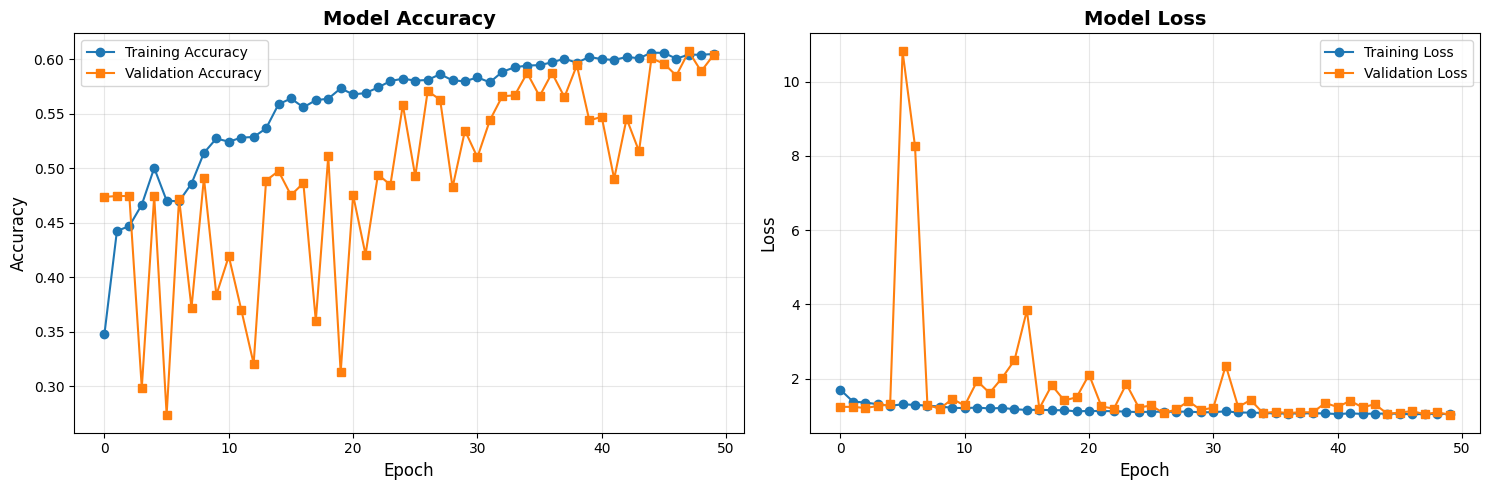


Final Training Metrics:
Training Accuracy: 0.6047
Validation Accuracy: 0.6038
Training Loss: 1.0511
Validation Loss: 1.0367


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")


## 10. Model Evaluation - Detailed Metrics


Evaluating on validation set...


2025-12-25 18:37:32.033068: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step

Validation Set Metrics:
  Accuracy: 0.6069
  Precision: 0.4536
  Recall: 0.6069
  F1-Score: 0.5190


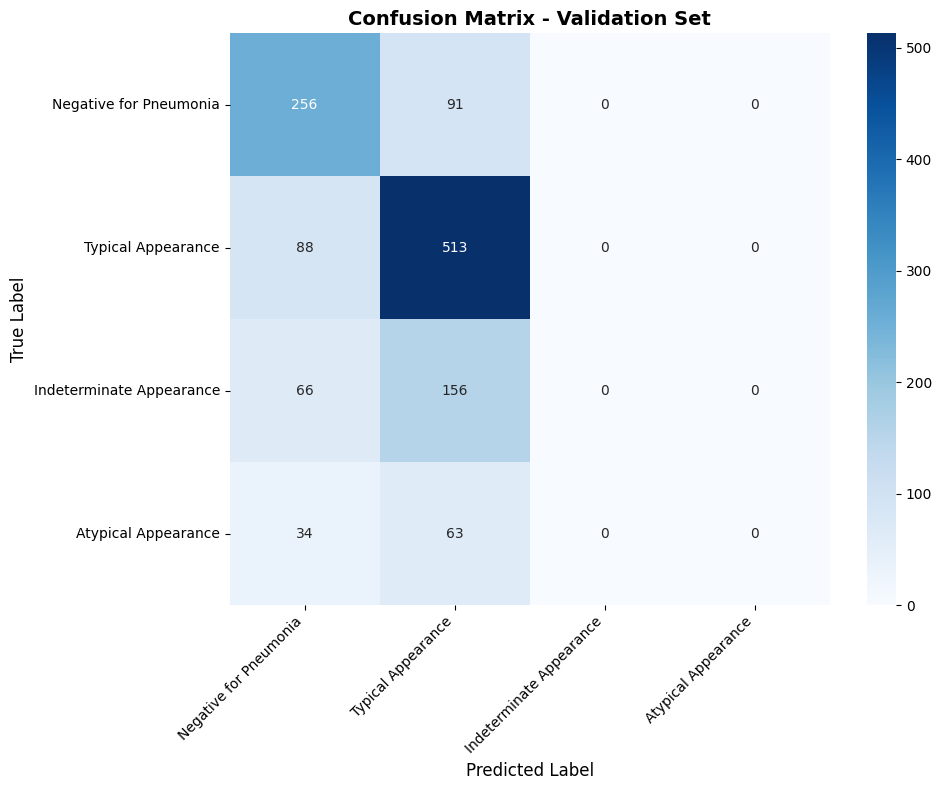


Classification Report:
                          precision    recall  f1-score   support

  Negative for Pneumonia       0.58      0.74      0.65       347
      Typical Appearance       0.62      0.85      0.72       601
Indeterminate Appearance       0.00      0.00      0.00       222
     Atypical Appearance       0.00      0.00      0.00        97

                accuracy                           0.61      1267
               macro avg       0.30      0.40      0.34      1267
            weighted avg       0.45      0.61      0.52      1267



In [14]:
# Load best model weights
model.load_weights(str(MODEL_WEIGHTS_PATH))

# Predict on validation set
print("Evaluating on validation set...")
val_predictions = model.predict(val_generator, verbose=1)
val_predicted_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_df['study_label'].values

# Calculate metrics
accuracy = accuracy_score(val_true_classes, val_predicted_classes)
precision = precision_score(val_true_classes, val_predicted_classes, average='weighted')
recall = recall_score(val_true_classes, val_predicted_classes, average='weighted')
f1 = f1_score(val_true_classes, val_predicted_classes, average='weighted')

print("\nValidation Set Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(val_true_classes, val_predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)])
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(val_true_classes, val_predicted_classes, 
                          target_names=[CLASS_LABELS[i] for i in range(NUM_CLASSES)]))


## 11. Save Model Architecture


In [15]:
# Save model architecture as JSON
model_json = model.to_json()
with open(MODEL_ARCHITECTURE_PATH, 'w') as json_file:
    json_file.write(model_json)

print(f"Model architecture saved to: {MODEL_ARCHITECTURE_PATH}")
print(f"Model weights saved to: {MODEL_WEIGHTS_PATH}")


Model architecture saved to: models/custom_covid19_model.json
Model weights saved to: models/custom_covid19_model.weights.h5


## 12. Model Serialization

Save the complete model package using joblib, including:
- Model architecture and weights
- Hyperparameters and configuration
- Preprocessing function
- Class labels
- Training history
- Validation metrics
- Model metadata


In [16]:
# Import model serialization module
from model_serialization import ModelSerializer

# Create serializer instance
serializer = ModelSerializer()

# Prepare augmentation configuration
augmentation_config = {
    'rotation_range': 15,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'shear_range': 0.1,
    'zoom_range': 0.1,
    'horizontal_flip': True,
    'fill_mode': 'nearest',
}

# Get validation metrics from evaluation (handle cases where variables might not exist)
val_metrics = {}
try:
    val_metrics['accuracy'] = accuracy
except NameError:
    pass

try:
    val_metrics['precision'] = precision
except NameError:
    pass

try:
    val_metrics['recall'] = recall
except NameError:
    pass

try:
    val_metrics['f1_score'] = f1
except NameError:
    pass

# Try to get loss from history if available
try:
    if 'history' in locals() and hasattr(history, 'history'):
        if 'val_loss' in history.history:
            val_metrics['loss'] = history.history['val_loss'][-1]
        elif 'loss' in history.history:
            val_metrics['loss'] = history.history['loss'][-1]
except:
    pass

# Get training history if available
training_history = {}
try:
    if 'history' in locals() and hasattr(history, 'history'):
        training_history = history.history
except:
    pass

# Save complete model package
model_file = serializer.save_model(
    model=model,
    hyperparameters={
        'IMG_SIZE': IMG_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'LEARNING_RATE': LEARNING_RATE,
        'NUM_CLASSES': NUM_CLASSES,
        'EPOCHS': EPOCHS,
    },
    class_labels=CLASS_LABELS,
    preprocessing_func=load_and_preprocess_image,
    augmentation_config=augmentation_config,
    training_history=training_history,
    validation_metrics=val_metrics,
    model_version="1.0",
    description="Custom CNN with Residual Connections and SE Attention for COVID-19 chest X-ray classification",
    compress=True
)

print(f"\n Complete model package saved!")
print(f"   You can now load this model using:")
print(f"   from model_serialization import ModelSerializer")
print(f"   serializer = ModelSerializer()")
print(f"   model_package = serializer.load_model('{model_file.parent}')")


   Model saved successfully!
   Location: models/saved_models/covid19_model_v1.0_20251225_183741/covid19_model_v1.0_20251225_183741.joblib
   Size: 215.56 MB
   Version: 1.0
   Validation Accuracy: 0.6069
   Validation Loss: 1.0367

 Complete model package saved!
   You can now load this model using:
   from model_serialization import ModelSerializer
   serializer = ModelSerializer()
   model_package = serializer.load_model('models/saved_models/covid19_model_v1.0_20251225_183741')


## 13. Test Set Evaluation

Evaluate the trained model on the test set to assess final performance.


In [17]:
# Prepare test set
from glob import glob
from pathlib import Path

TEST_SPLIT_CSV = DATA_DIR / 'meta_test.csv'
TEST_IMAGES_DIR = DATA_DIR / '256px' / 'test' / 'test'

# Build lookup dictionary for test images
def build_test_image_lookup_dict():
    """Build a dictionary mapping ImageInstanceUID to full file path for test images"""
    lookup_dict = {}
    for file_path in Path(TEST_IMAGES_DIR).glob("*.jpg"):
        filename = file_path.name
        # Extract ImageInstanceUID from filename (last part before .jpg)
        # Pattern: {StudyInstanceUID}_{something}_{ImageInstanceUID}.jpg
        parts = filename.rsplit('_', 1)  # Split from right, get last part
        if len(parts) == 2:
            image_id = parts[1].replace('.jpg', '')
            lookup_dict[image_id] = str(file_path)
    return lookup_dict

# Load test metadata
print("Loading test set metadata...")
test_meta_df = pd.read_csv(TEST_SPLIT_CSV)

print(f"Test metadata samples: {len(test_meta_df)}")
print(f"\nTest metadata columns: {test_meta_df.columns.tolist()}")

# Build image lookup dictionary
print("\nBuilding test image lookup dictionary...")
test_image_lookup = build_test_image_lookup_dict()
print(f"Found {len(test_image_lookup)} test image files")

# Map image paths to test metadata
test_meta_df['image_path'] = test_meta_df['ImageInstanceUID'].map(test_image_lookup)

# Filter to only rows where we found images
test_df = test_meta_df[test_meta_df['image_path'].notna()].copy()

print(f"\nTest samples with images found: {len(test_df)}")
print(f"Test samples missing images: {len(test_meta_df) - len(test_df)}")

# Note: The test set doesn't have labels, so we can only make predictions, not calculate accuracy
# If you have test labels elsewhere, you can add them to test_df before evaluation


Loading test set metadata...
Test metadata samples: 1263

Test metadata columns: ['ImageInstanceUID', 'width', 'height']

Building test image lookup dictionary...
Found 1263 test image files

Test samples with images found: 1263
Test samples missing images: 0


In [18]:
# Create test data generator
# Note: Since test set doesn't have labels, we'll create a modified generator that only returns images
class TestDataGenerator(tf.keras.utils.Sequence):
    """Custom data generator for test images (no labels)"""
    
    def __init__(self, dataframe, batch_size=BATCH_SIZE):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = list(range(idx * self.batch_size, min((idx + 1) * self.batch_size, len(self.df))))
        batch_df = self.df.iloc[batch_indices]
        
        X = np.zeros((len(batch_df), IMG_SIZE, IMG_SIZE, 3))
        
        for i, (_, row) in enumerate(batch_df.iterrows()):
            # Load and preprocess image
            img = load_and_preprocess_image(row['image_path'])
            X[i] = img
        
        return X

# Create test generator
test_generator = TestDataGenerator(test_df, batch_size=BATCH_SIZE)
print(f"Test batches: {len(test_generator)}")
print(f"Test samples: {len(test_df)}")


Test batches: 20
Test samples: 1263


In [19]:
# Load best model weights and make predictions on test set
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

# Ensure model weights are loaded
model.load_weights(str(MODEL_WEIGHTS_PATH))
print(f"Loaded model weights from: {MODEL_WEIGHTS_PATH}")

# Make predictions
print("\nGenerating predictions on test set...")
test_predictions = model.predict(test_generator, verbose=1)
test_predicted_classes = np.argmax(test_predictions, axis=1)
test_predicted_probs = np.max(test_predictions, axis=1)

print(f"\nPredictions generated for {len(test_df)} test samples")
print(f"Prediction shape: {test_predictions.shape}")

# Add predictions to test dataframe
test_df['predicted_class'] = test_predicted_classes
test_df['predicted_label'] = test_df['predicted_class'].map(lambda x: CLASS_LABELS[x])
test_df['prediction_confidence'] = test_predicted_probs

# Show prediction distribution
print("\nPrediction Distribution:")
print(test_df['predicted_label'].value_counts())

print("\nPrediction Confidence Statistics:")
print(f"  Mean confidence: {test_predicted_probs.mean():.4f}")
print(f"  Std confidence: {test_predicted_probs.std():.4f}")
print(f"  Min confidence: {test_predicted_probs.min():.4f}")
print(f"  Max confidence: {test_predicted_probs.max():.4f}")


TEST SET EVALUATION
Loaded model weights from: models/custom_covid19_model.weights.h5

Generating predictions on test set...
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2025-12-25 18:38:01.496423: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-25 18:38:01.496463: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-25 18:38:01.979731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 4 bytes spill stores, 4 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step

Predictions generated for 1263 test samples
Prediction shape: (1263, 4)

Prediction Distribution:
predicted_label
Typical Appearance        864
Negative for Pneumonia    399
Name: count, dtype: int64

Prediction Confidence Statistics:
  Mean confidence: 0.5981
  Std confidence: 0.1588
  Min confidence: 0.2776
  Max confidence: 1.0000


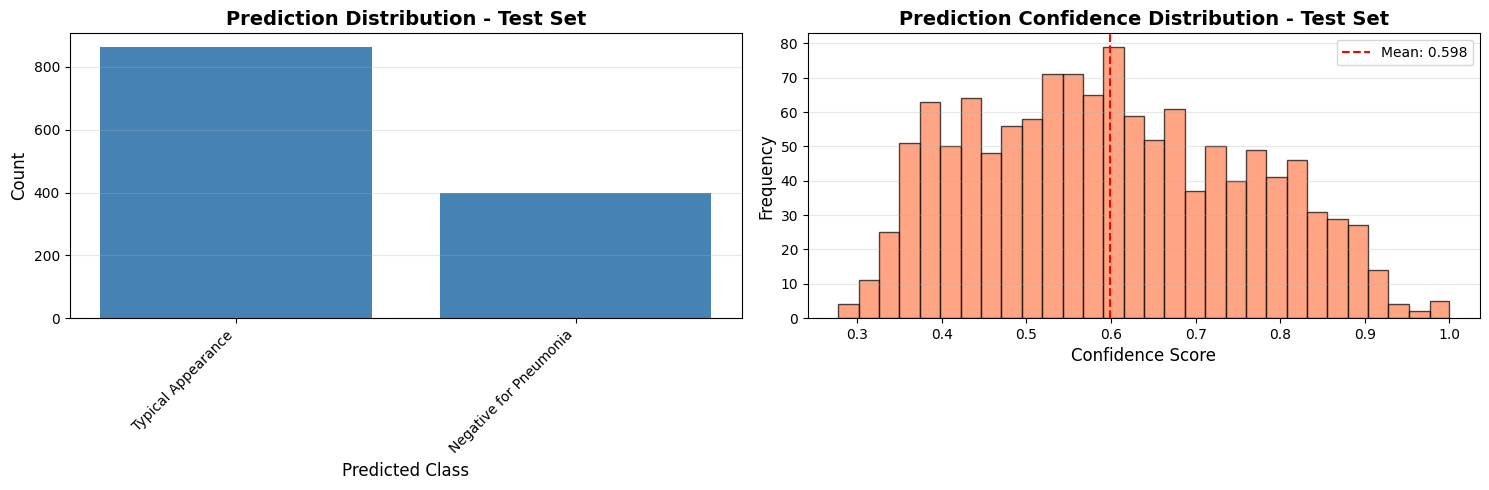

Test Set Evaluation Summary:
  Total test samples: 1263
  Most common prediction: Typical Appearance (864 samples, 68.4%)
  Average prediction confidence: 0.5981


In [20]:
# Visualize test set predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Prediction distribution
pred_counts = test_df['predicted_label'].value_counts()
axes[0].bar(range(len(pred_counts)), pred_counts.values, color='steelblue')
axes[0].set_xticks(range(len(pred_counts)))
axes[0].set_xticklabels(pred_counts.index, rotation=45, ha='right')
axes[0].set_title('Prediction Distribution - Test Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Confidence distribution
axes[1].hist(test_predicted_probs, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Prediction Confidence Distribution - Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Confidence Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(test_predicted_probs.mean(), color='red', linestyle='--', 
                label=f'Mean: {test_predicted_probs.mean():.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary
print("Test Set Evaluation Summary:")
print(f"  Total test samples: {len(test_df)}")
print(f"  Most common prediction: {pred_counts.index[0]} ({pred_counts.iloc[0]} samples, {100*pred_counts.iloc[0]/len(test_df):.1f}%)")
print(f"  Average prediction confidence: {test_predicted_probs.mean():.4f}")


In [21]:
# Save test predictions to CSV
test_predictions_df = test_df[['ImageInstanceUID', 'predicted_class', 'predicted_label', 'prediction_confidence']].copy()

# Add individual class probabilities
for i, label in CLASS_LABELS.items():
    test_predictions_df[f'prob_{label}'] = test_predictions[:, i]

# Save to CSV
test_predictions_path = MODEL_DIR / 'test_predictions.csv'
test_predictions_df.to_csv(test_predictions_path, index=False)
print(f"Test predictions saved to: {test_predictions_path}")

# Display sample predictions
print("\nSample Test Predictions (first 10):")
print(test_predictions_df.head(10).to_string())

Test predictions saved to: models/test_predictions.csv

Sample Test Predictions (first 10):
  ImageInstanceUID  predicted_class         predicted_label  prediction_confidence  prob_Negative for Pneumonia  prob_Typical Appearance  prob_Indeterminate Appearance  prob_Atypical Appearance
0     8d6dea06a032                1      Typical Appearance               0.724121                     0.084656                 0.724121                       0.145264                  0.046204
1     695e2c6dede4                0  Negative for Pneumonia               0.723145                     0.723145                 0.079895                       0.127075                  0.069641
2     9850b5470fd6                1      Typical Appearance               0.676270                     0.084351                 0.676270                       0.163452                  0.075562
3     9f6cc74b0062                1      Typical Appearance               0.778809                     0.055328                 0.77